# Exoplanet Discovery Method Classifier

**Task**: predict whether a confirmed exoplanet was discovered via **Transit** photometry or **Radial Velocity**, using its orbital, physical, and host-star parameters.

**Source**: NASA Exoplanet Archive, Planetary Systems Composite Parameters (PSCompPars) table, `data.csv`.

Pipeline: **select features → filter to 2 classes → train/test split → impute → scale → PCA → logistic regression**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


## 1. Load data

The file has a ~88 line comment header (`#`) from the archive export, so it's skipped automatically.

In [2]:
df = pd.read_csv('data.csv', comment='#')
print(df.shape)
df.head(3)

(6372, 84)


,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbsmaxlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_radj,pl_radjerr1,pl_radjerr2,pl_radjlim,pl_bmasse,pl_bmasseerr1,pl_bmasseerr2,pl_bmasselim,pl_bmassj,pl_bmassjerr1,pl_bmassjerr2,pl_bmassjlim,pl_bmassprov,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_insol,pl_insolerr1,pl_insolerr2,pl_insollim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,ttv_flag,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_mass,st_masserr1,st_masserr2,st_masslim,st_met,st_meterr1,st_meterr2,st_metlim,st_metratio,st_logg,st_loggerr1,st_loggerr2,st_logglim,rastr,ra,decstr,dec,sy_dist,sy_disterr1,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007,Xinglong Station,0,323.21000,0.06,-0.05,0.0,1.178,0.00,0.00,0.0,12.2,NaN,NaN,0.0,1.09,NaN,NaN,0.0,4914.898486,39.092894,-39.728551,0.0,15.464,0.123,-0.125,0.0,Msini,0.238,0.007,-0.007,0.0,68.5387,26.7260,-26.7260,0.0,803.26,NaN,NaN,0.0,0,G8 III,4874.0,NaN,NaN,0.0,13.76,2.85,-2.45,0.0,2.09,0.64,-0.63,0.0,-0.26,0.1,-0.1,0.0,[Fe/H],2.45,0.08,-0.08,0.0,12h20m42.91s,185.178779,+17d47m35.71s,17.793252,93.1846,1.9238,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,-3.20,0.0,1.530,0.07,-0.07,0.0,12.3,NaN,NaN,0.0,1.09,NaN,NaN,0.0,4684.814200,794.575000,-794.575000,0.0,14.740,2.500,-2.500,0.0,Msini,0.080,0.030,-0.030,0.0,114.8502,10.7244,-10.7244,0.0,896.43,48.4,-48.4,0.0,0,K4 III,4213.0,46.0,-46.0,0.0,29.79,2.84,-2.84,0.0,2.78,0.69,-0.69,0.0,-0.02,NaN,NaN,0.0,[Fe/H],1.93,0.07,-0.07,0.0,15h17m05.90s,229.274595,+71d49m26.19s,71.823943,125.3210,1.9765,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008,Okayama Astrophysical Observatory,0,186.76000,0.11,-0.12,0.0,0.775,0.00,0.00,0.0,13.1,NaN,NaN,0.0,1.16,NaN,NaN,0.0,1131.151301,36.232438,-38.775066,0.0,3.559,0.114,-0.122,0.0,Msini,0.000,NaN,NaN,0.0,115.1634,17.4042,-17.4042,0.0,909.92,NaN,NaN,0.0,0,K0 III,4888.0,NaN,NaN,0.0,11.55,1.12,-0.51,0.0,1.78,0.43,-0.29,0.0,-0.21,0.1,-0.1,0.0,[Fe/H],2.55,0.06,-0.07,0.0,23h31m17.80s,352.824150,+39d14m09.01s,39.235837,75.4392,0.7140,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826


## 2. Select the target and restrict to two classes

`discoverymethod` is fully populated (0 missing), but it has 10 categories, most of them tiny
(Microlensing, Imaging, TTV, etc. — under 300 rows each and often not comparable in feature coverage).
We keep the two dominant, well-populated methods so the task is a clean binary problem instead of a
severely imbalanced 10-way one.

In [3]:
print(df['discoverymethod'].value_counts())

mask = df['discoverymethod'].isin(['Transit', 'Radial Velocity'])
data = df.loc[mask].copy()
print(f"\nKept {len(data)} / {len(df)} rows ({len(data)/len(df):.1%})")

data['target'] = (data['discoverymethod'] == 'Transit').astype(int)  # 1 = Transit, 0 = Radial Velocity
data['target'].value_counts(normalize=True)

discoverymethod
Transit                          4709
Radial Velocity                  1202
Microlensing                      292
Imaging                            97
Transit Timing Variations          29
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

Kept 5911 / 6372 rows (92.8%)


target
1    0.79665
0    0.20335
Name: proportion, dtype: float64

## 3. Feature selection

We use physical, orbital, and stellar parameters — the kind of quantities that describe the planet
and its star, independent of *how* they were measured.

**Deliberately excluded:**
- All `*err1` / `*err2` / `*lim` columns (measurement uncertainties and limit flags). These directly
  encode measurement *precision*, which differs systematically between RV and Transit pipelines —
  including them would let the model cheat by learning "how precisely was this measured" instead of
  "what does this planet/star look like," which isn't the physical question we're asking.
- Identifiers and text fields (`pl_name`, `hostname`, `disc_facility`, coordinates, spectral type text).
- `pl_bmassprov`, `ttv_flag`, `pl_controv_flag` — these describe *how* the measurement was produced or
  flagged, which leaks the discovery-method label almost by definition.
- `disc_year` — a mix of survey-era effects, not a physical property of the planet/star.

**Kept:** orbital period & semi-major axis, planet radius & mass, eccentricity, insolation,
equilibrium temperature, stellar temperature/radius/mass/metallicity, system distance and brightness.

In [4]:
FEATURES = [
    'pl_orbper', 'pl_orbsmax',          # orbit size/period
    'pl_rade', 'pl_bmasse',             # planet radius & mass
    'pl_orbeccen',                      # eccentricity
    'pl_insol', 'pl_eqt',               # insolation & equilibrium temperature
    'st_teff', 'st_rad', 'st_mass', 'st_met',  # host star properties
    'sy_dist', 'sy_vmag',               # how far away / how bright the host star is
]

X = data[FEATURES].apply(pd.to_numeric, errors='coerce')
y = data['target']

print("Missing value rate per feature:")
print((X.isna().mean() * 100).round(1).astype(str) + ' %')

Missing value rate per feature:
pl_orbper       0.0 %
pl_orbsmax      6.8 %
pl_rade         0.6 %
pl_bmasse       0.4 %
pl_orbeccen    11.7 %
pl_insol        4.2 %
pl_eqt          3.5 %
st_teff         0.1 %
st_rad          0.1 %
st_mass         0.0 %
st_met          4.6 %
sy_dist         0.3 %
sy_vmag         0.1 %
dtype: str


## 4. Train / test split

Split **before** any imputation, scaling, or PCA fitting — all of those must be fit only on the
training fold so that no information from the held-out test set leaks into preprocessing.
Stratified on the target to preserve the ~80/20 class balance in both folds.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (4728, 13), Test: (1183, 13)
Train class balance:
target
1    0.796743
0    0.203257
Name: proportion, dtype: float64


## 5. Preprocessing + PCA + classifier, as one fitted pipeline

- **Median imputation**: several columns (`pl_orbeccen`, `pl_insol`, `st_met`, ...) have missing values;
  median is robust to the heavy skew/outliers common in astrophysical measurements (e.g. orbital period
  spans days to tens of thousands of days).
- **Standardization**: required before PCA, since PCA finds directions of maximum variance and would
  otherwise be dominated by whichever feature happens to have the largest raw scale (e.g. `sy_dist` in
  parsecs vs. `pl_orbeccen` in [0, 1]).
- **PCA**: compresses the 13 correlated features (e.g. radius and mass are correlated; insolation,
  equilibrium temperature, and orbital distance are all related) down to a smaller set of orthogonal
  components, fit on the training data only.
- **Classifier**: plain logistic regression — a simple, fast linear baseline, appropriate for a first
  pass and easy to sanity-check.

In [6]:
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=0.90, random_state=RANDOM_STATE)),  # keep enough PCs for 90% variance
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

pipe.fit(X_train, y_train)

n_components = pipe.named_steps['pca'].n_components_
print(f"PCA kept {n_components} components to explain >=90% of variance")

PCA kept 8 components to explain >=90% of variance


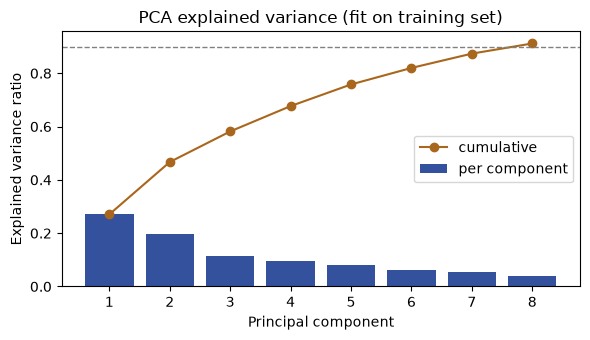

In [7]:
explained = pipe.named_steps['pca'].explained_variance_ratio_
cum = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(1, len(explained) + 1), explained, color='#33519d', label='per component')
ax.plot(range(1, len(explained) + 1), cum, color='#a8671c', marker='o', label='cumulative')
ax.axhline(0.90, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA explained variance (fit on training set)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate on the held-out test set

In [8]:
pred = pipe.predict(X_test)

acc = accuracy_score(y_test, pred)
baseline = y_test.value_counts(normalize=True).max()
print(f"Test accuracy: {acc:.3f}")
print(f"Majority-class baseline: {baseline:.3f}")
print()
print(classification_report(y_test, pred, target_names=['Radial Velocity', 'Transit']))

Test accuracy: 0.952
Majority-class baseline: 0.796

                 precision    recall  f1-score   support

Radial Velocity       0.92      0.83      0.88       241
        Transit       0.96      0.98      0.97       942

       accuracy                           0.95      1183
      macro avg       0.94      0.91      0.92      1183
   weighted avg       0.95      0.95      0.95      1183



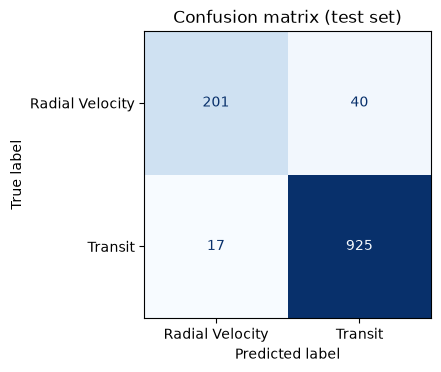

In [9]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Radial Velocity', 'Transit'])
fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

## 7. Takeaways

- After compressing 13 standardized features down to the components needed for 90% of variance, a
  plain logistic regression still clears the majority-class baseline by a wide margin — the task has
  real, PCA-preserved signal rather than needing raw features or a complex model.
- All preprocessing (imputer medians, scaler mean/std, PCA axes) was fit **only on the training fold**,
  so the reported test accuracy reflects genuine generalization, not leakage from the test set.
- Excluding the uncertainty/limit/provenance columns keeps the task honest: the model has to infer
  discovery method from what the planet and star actually *are*, not from artifacts of how precisely
  they were measured.